In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/train.csv")
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


In [32]:
print(df.shape)

(9800, 18)


In [33]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [34]:
df["Order Date"]= pd.to_datetime(df["Order Date"],dayfirst=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   object        
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [35]:
#What is the earliest Order Date and what is the latest Order Date?
print(df["Order Date"].min())
print(df["Order Date"].max())

2015-01-03 00:00:00
2018-12-30 00:00:00


In [36]:
df["Order Date"].head(10)

0   2017-11-08
1   2017-11-08
2   2017-06-12
3   2016-10-11
4   2016-10-11
5   2015-06-09
6   2015-06-09
7   2015-06-09
8   2015-06-09
9   2015-06-09
Name: Order Date, dtype: datetime64[ns]

In [37]:
#How much total sales did the company generate in each year?
yearly_sales=df.groupby(df["Order Date"].dt.year)["Sales"].sum().reset_index()
yearly_sales.columns=["Order Year","Total Sales"]
yearly_sales

,Order Year,Total Sales
0,2015,479856.2081
1,2016,459436.0054
2,2017,600192.5500
3,2018,722052.0192


In [38]:
#How do sales change month-by-month from 2015 to 2018?
monthly_sales = (df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum().reset_index())
monthly_sales.columns=["Order Month","Total Sales"]
monthly_sales

,Order Month,Total Sales
0,2015-01,14205.7070
1,2015-02,4519.8920
2,2015-03,55205.7970
3,2015-04,27906.8550
4,2015-05,23644.3030
5,2015-06,34322.9356
6,2015-07,33781.5430
7,2015-08,27117.5365
8,2015-09,81623.5268
9,2015-10,31453.3930


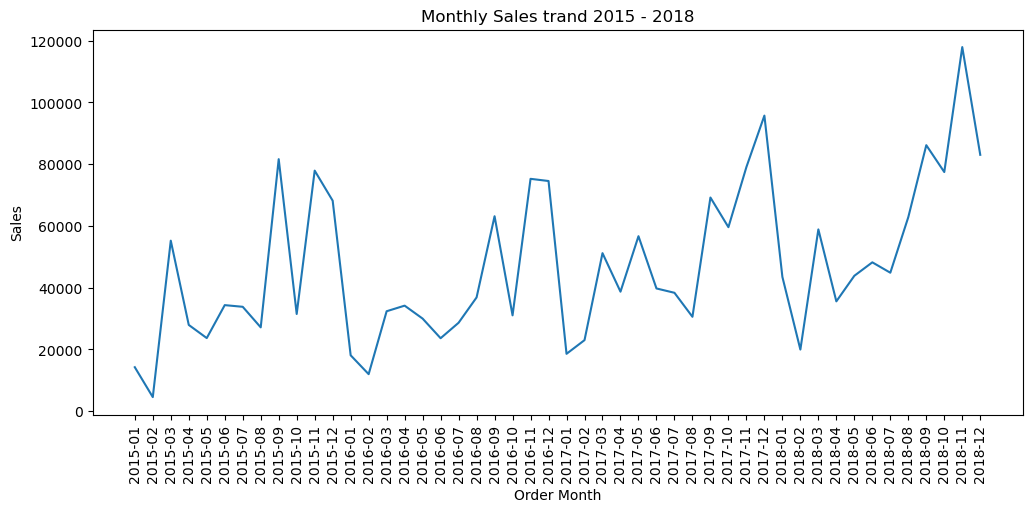

In [39]:
monthly_sales["Order Month"] = monthly_sales["Order Month"].astype(str)
plt.figure(figsize=(12,5))
sns.lineplot(x="Order Month",y="Total Sales",data=monthly_sales)
plt.xticks(rotation=90)
plt.xlabel("Order Month")
plt.ylabel("Sales")
plt.title("Monthly Sales trand 2015 - 2018")
plt.show()


In [40]:
#Top 5 highest-sales months
monthly_sales.sort_values("Total Sales",inplace=True,ascending=False)

In [41]:
monthly_sales[0:5]

,Order Month,Total Sales
46,2018-11,117938.1550
35,2017-12,95739.1210
44,2018-09,86152.8880
47,2018-12,83030.3888
8,2015-09,81623.5268


In [42]:
yearly_sales["Yoy Growth"] = ((yearly_sales["Total Sales"]-yearly_sales["Total Sales"].shift(1))/yearly_sales["Total Sales"].shift(1))*100

In [43]:
yearly_sales

,Order Year,Total Sales,Yoy Growth
0,2015,479856.2081,NaN
1,2016,459436.0054,-4.255484
2,2017,600192.5500,30.636812
3,2018,722052.0192,20.303396


In [44]:
#we can also Use a .pct_change() instant of a this farmula for fast calculation=

In [45]:
#Which year had the highest YoY growth?
yearly_sales.loc[yearly_sales["Yoy Growth"].idxmax()]

Order Year       2017.000000
Total Sales    600192.550000
Yoy Growth         30.636812
Name: 2, dtype: float64

2015 → $479.9K

2016 → $459.4K  ↓ 4.26%

2017 → $600.2K  ↑ 30.64%  ← highest growth

2018 → $722.1K  ↑ 20.30%